In [33]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from scipy.optimize import curve_fit

In [64]:

num_levels = 4
a = qt.destroy(num_levels)

omega = 2 * np.pi * 5.0  # GHz

H_0 = omega * a.dag() * a


times = np.linspace(0, 5000, 1001)  # ns

initial_phase = 0
psi0 = (qt.basis(num_levels, 0) + np.exp(1j * initial_phase * np.pi) * qt.basis(num_levels, 1)).unit()

e_ops = [a.dag() * a, a + a.dag(), 1j*(a.dag() - a)]

T2 = 500 # ns
gamma_2 = 1 / T2

T1 = 50_000
T1 = 1000
# T1 = None

if T1 is None:
    gamma_1 = 0
else:
    gamma_1 = 1 / T1

gamma_phi = gamma_2 - 1/2*gamma_1

assert gamma_phi >= 0, "Inconsistent T1 and T2 values!"

c_ops = [np.sqrt(gamma_phi) * a.dag() * a]

if gamma_1 > 0:
    c_ops.append(np.sqrt(gamma_1) * a)

In [65]:
result = qt.mesolve(H_0, psi0, times, e_ops=e_ops, c_ops=c_ops)

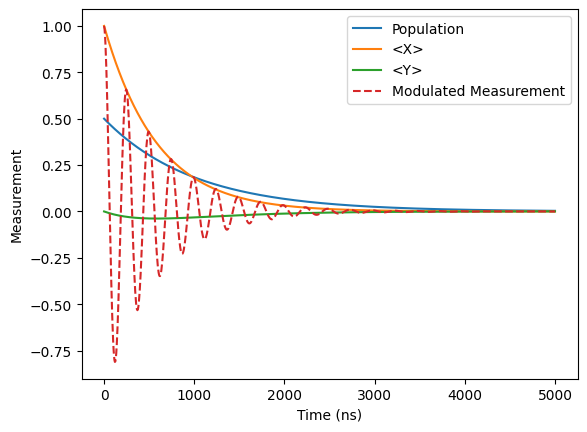

In [66]:

plt.plot(times, result.expect[0], label='Population')
plt.plot(times, result.expect[1], label='<X>')
plt.plot(times, result.expect[2], label='<Y>')

detuning = 0.004*2*np.pi # GHz

modulated_measurement = result.expect[1]*np.cos(detuning*times) + result.expect[2]*np.sin(detuning*times)
plt.plot(times, modulated_measurement, label='Modulated Measurement', linestyle='--')

plt.xlabel('Time (ns)')
plt.ylabel('Measurement')
plt.legend()

plt.show()

In [67]:
def sin_fit(t, T2, delta):
    return np.exp(-t / T2) * np.cos(delta * t)

In [68]:
popt, pcov = curve_fit(sin_fit, times, modulated_measurement, p0=(T2, detuning))

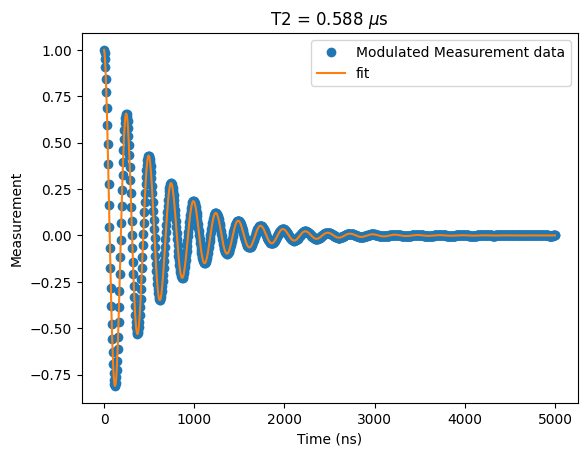

In [69]:
plt.plot(times, modulated_measurement, label='Modulated Measurement data', marker='o', linestyle='')
plt.plot(times, sin_fit(times, *popt), label='fit')

plt.xlabel('Time (ns)')
plt.ylabel('Measurement')
plt.legend()

plt.title('T2 = %.3f $\mu$s' % (popt[0] / 1000))

plt.show()